![](Images/banner_health_analytics.png){fig-align="center" width="100%"}



### Module 07: Spatial Epidemiology


# Disease Mapping & Bayesian Smoothing

**Learning objectives**
- Understand the small-area estimation problem: unstable rates in sparse populations
- Implement empirical Bayes smoothing (James-Stein, gamma-Poisson)
- Conceptualise the BYM (Besag-York-Mollié) CAR model structure
- Compare raw SMR vs smoothed estimates visually and statistically
- Apply MCMC-based spatial smoothing using PyMC (when available)
- Assess shrinkage patterns in Bayesian disease mapping

**Estimated time:** 3 hours | **Level:** Advanced  
**Libraries:** `numpy`, `scipy`, `matplotlib`, `pymc` (optional)


## 1. Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
from scipy.ndimage import gaussian_filter; from scipy.spatial import cKDTree
warnings.filterwarnings("ignore"); import os; os.makedirs("/tmp/mod07", exist_ok=True)
plt.rcParams.update({"figure.dpi":120,"figure.facecolor":"white",
                     "axes.spines.top":False,"axes.spines.right":False})


## 2. The Small-Area Estimation

 Small-Area Estimation (SAE) refers to statistical methods used to produce reliable estimates of quantities (such as disease rates) for small geographic areas or population subgroups, where direct survey data is sparse or highly variable. Instead of relying only on local data — which may be noisy or unreliable for small places — SAE combines information from similar areas, related predictors, or statistical models to "borrow strength." This helps stabilize estimates, reduce random error, and provide more trustworthy results, especially in regions with limited data. In public health, SAE is crucial for mapping disease rates in all counties or neighborhoods, not just places with large populations or many survey respondents.

### 2.1 The Small-Area Estimation Problem

Imagine you run a national health survey and someone asks you for the diabetes rate in *every county*. The catch: a survey designed for national numbers might only catch six people in some small rural county. A rate computed from six people is basically noise — one unlucky draw reads 0%, another reads 33%. That "just use whoever you sampled there" number is called the *direct estimate*, and in small areas it's too wobbly to trust. Small Area Estimation (SAE) is the set of tricks for getting believable numbers for those little areas anyway.

**The core move: borrowing strength.** Instead of trusting those six people alone, SAE blends them with information from outside the county. It borrows from two places:

- *Predictors that exist everywhere.* Obesity, age structure, poverty, food access come from the census and administrative records for every county — no survey needed. If you know how those track with diabetes (a regression), you can predict a county's rate even where you sampled almost nobody.
- *Neighbouring or similar areas.* Nearby counties carry information about each other, so you let them lend each other statistical weight (spatial smoothing).

Usually you use both.

**The mechanism: shrinkage.** The final estimate is a weighted average of the noisy local direct estimate and the model's prediction — and the weighting is the clever bit, because it adapts to how much local data you have. Big sample in a county → trust the direct number, barely nudge it. Tiny sample → lean hard on the model. Estimates get "shrunk" toward the model prediction by an amount proportional to how unreliable they are. You trade a little bias for a big cut in variance, and on average land much closer to the truth.

The everyday analogy is rating a restaurant from only three reviews: you don't take those three at face value, you nudge them toward what you'd expect from similar restaurants nearby — and the fewer reviews there are, the more you rely on that expectation.

**Names you'll bump into.** When you only have the aggregated estimate per area plus area-level covariates, the classic tool is the *Fay–Herriot* area-level model. When you have individual respondent records plus covariates, it's the *Battese–Harter–Fuller* unit-level model. Bolt on spatial or random effects (often estimated in a Bayesian / INLA framework) and you're in modern SAE.

**Where you've already met it.** The county diabetes prevalence you've been running GWR and GWC on is almost certainly an SAE product — CDC's diabetes surveillance and the PLACES project publish county estimates built with model-based small area estimation, precisely because no survey measures every county directly. So your local-regression work sits one layer on top of SAE output.

**The catch.** All of this leans on the model being reasonable. If the model is wrong, or a county is genuinely unusual in a way the covariates don't capture, SAE will cheerfully smooth that real signal away — the precision you gained was borrowed against an assumption. That tension between design-based (trust the sample) and model-based (trust the model) thinking is basically the whole craft of the field.



**Problem:** Observed SMR = O_i / E_i is unstable for areas with small populations.

A county with expected deaths E=2 and observed O=4 has SMR=2.0, suggesting 100% excess mortality — but this could easily be random variation.



**Key insight:** Raw rates have high variance in low-population areas. Bayesian methods "borrow strength" from neighbouring areas and the overall mean.


| Method | Shrinkage target | Spatially informed? |
|--------|-----------------|---------------------|
| Raw SMR | None | No |
| Empirical Bayes (EB) | Overall mean | No |
| BYM/CAR | Spatial neighbours | Yes |
| Full Bayesian MCMC | Prior + data | Yes (BYM) |




| Method | Shrinkage target | Spatially informed? |
|--------|-----------------|---------------------|
| Raw SMR | None | No |
| Empirical Bayes (EB) | Overall mean | No |
| BYM/CAR | Spatial neighbours | Yes |
| Full Bayesian MCMC | Prior + data | Yes (BYM) |


### 2.2 Small Area Estimation on County Level Data

In [2]:
"""
Small Area Estimation demo on US county data.

Setup: take the published county diabetes prevalence as the (pretend) TRUTH.
Simulate a national survey that samples a small, highly variable number of
respondents per county, and count diabetes cases as Binomial(n_c, p_true).
  - DIRECT estimate  p_hat = cases / respondents   (design-based)
  - FAY-HERRIOT area-level model borrows strength from covariates known for
    every county (obesity, age65+, exercise access, food environment) and
    shrinks each noisy direct estimate toward the model fit.
Shows why small samples break the direct estimate and how SAE repairs it.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm

mpl.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10})
rng = np.random.default_rng(7)

# --------------------------------------------------------------------------- #
# Truth + covariates
# --------------------------------------------------------------------------- #
df= pd.read_csv("Data/usa_data.csv")
p_true = df["y_diabetes_prevalence_adults_with_diabetes"].to_numpy(float) / 100.0
Z = df[["chr_adult_obesity", "chr_65_and_older_65_and_over",
        "chr_access_to_exercise_opportunities",
        "chr_food_environment_index"]].to_numpy(float)
coords = df[["centroid_x_m", "centroid_y_m"]].to_numpy(float)
m = len(df)

# --------------------------------------------------------------------------- #
# Simulate the survey  (this is the "raw data")
# --------------------------------------------------------------------------- #
# respondents per county: median ~25, some as few as 5, a few in the hundreds
n_c = np.clip(np.round(rng.lognormal(mean=np.log(25), sigma=0.9, size=m)), 5, None).astype(int)
cases = rng.binomial(n_c, p_true)                 # observed diabetes cases
p_dir = cases / n_c                               # DIRECT estimate

# design-based sampling variance of each direct estimate (stabilised)
p_tilde = (cases + 0.5) / (n_c + 1)
D = p_tilde * (1 - p_tilde) / n_c

# --------------------------------------------------------------------------- #
# Fay-Herriot area-level model explanation:
# This model is designed for small area estimation (SAE), where direct estimates can be highly variable due to small sample sizes in each area (here, counties).
# The observed (direct) estimate for area i, p_dir[i], is modeled as:
#     p_dir = X * beta + v + e
# - X is the matrix of known county-level covariates (like obesity, age structure, etc), and beta is a vector of regression coefficients.
# - v is a random effect for each area, assumed v ~ N(0, s2), representing unobserved heterogeneity between counties.
# - e is a sampling error term reflecting survey variability, assumed e ~ N(0, D), where D is the variance of the direct estimator for each county.
# This hierarchical model "borrows strength" across counties by shrinking noisy direct estimates toward predictions from the covariates, improving estimates especially in counties with small survey samples.
# --------------------------------------------------------------------------- #
X = np.column_stack([np.ones(m), (Z - Z.mean(0)) / Z.std(0)])   # standardise covars

def fh_gls(X, y, D, s2):
    Wv = 1.0 / (s2 + D)
    XtW = X.T * Wv
    beta = np.linalg.solve(XtW @ X, XtW @ y)
    return beta

# moment estimate of the between-area variance s2, then 2 GLS refinements
beta = np.linalg.lstsq(X, p_dir, rcond=None)[0]
resid = p_dir - X @ beta
p = X.shape[1]
s2 = max((resid @ resid - D.sum()) / (m - p), 1e-6)   # Fay-Herriot moment est.
for _ in range(2):
    beta = fh_gls(X, p_dir, D, s2)
    resid = p_dir - X @ beta
    s2 = max((np.sum(resid**2 * (s2 / (s2 + D))) ) / (m - p), 1e-6)

gamma = s2 / (s2 + D)                # shrinkage weight: ~1 big sample, ~0 tiny
p_fh = gamma * p_dir + (1 - gamma) * (X @ beta)      # EBLUP

# --------------------------------------------------------------------------- #
# How much did we gain?
# --------------------------------------------------------------------------- #
def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2)) * 100      # in percentage points

print(f"Respondents per county : min {n_c.min()}, median {int(np.median(n_c))}, "
      f"max {n_c.max()}")
print(f"RMSE vs truth  DIRECT  : {rmse(p_dir, p_true):.2f} pts")
print(f"RMSE vs truth  FAY-HER.: {rmse(p_fh, p_true):.2f} pts")
small = n_c <= 15
print(f"  among the {small.sum()} smallest-sample counties (n<=15):")
print(f"    DIRECT   RMSE       : {rmse(p_dir[small], p_true[small]):.2f} pts")
print(f"    FAY-HER. RMSE       : {rmse(p_fh[small], p_true[small]):.2f} pts")

# save the simulated dataset + estimates
pd.DataFrame({
    "fips": df["fips"], "county": df["county"], "state": df["state_abbr"],
    "p_true_pct": p_true * 100, "respondents": n_c, "cases": cases,
    "p_direct_pct": p_dir * 100, "p_fayherriot_pct": p_fh * 100,
    "shrinkage_gamma": gamma,
}).to_csv("Data/sae_simulation.csv", index=False)


Respondents per county : min 5, median 24, max 443
RMSE vs truth  DIRECT  : 7.14 pts
RMSE vs truth  FAY-HER.: 2.78 pts
  among the 960 smallest-sample counties (n<=15):
    DIRECT   RMSE       : 10.09 pts
    FAY-HER. RMSE       : 2.83 pts


### 2.3 Fay-Herriot Area-level Model

This method helps us get better estimates for each county, especially where we don't have a lot of data. It takes what we know about each county (like age, obesity, etc.) and combines it with the raw survey results. If a county has few survey responses (very noisy), it "blends" the result with what we predict using the other info.  The final estimate is a smart mix: if the county has lots of data, the survey result dominates; if not, the prediction from covariates (and all counties) helps out more.

This model is designed for small area estimation (SAE), where direct estimates can be highly variable due to small sample sizes in each area (here, counties).

The observed (direct) estimate for area i, p_dir[i], is modeled as:

     p_dir = X * beta + v + e

 - X is the matrix of known county-level covariates (like obesity, age structure, etc), and beta is a vector of regression coefficients.
 - v is a random effect for each area, assumed v ~ N(0, s2), representing unobserved heterogeneity between counties.
 - e is a sampling error term reflecting survey variability, assumed e ~ N(0, D), where D is the variance of the direct estimator for each county.

 This hierarchical model "borrows strength" across counties by shrinking noisy direct estimates toward predictions from the covariates, improving estimates especially in counties with small survey samples.

In [3]:
# --------------------------------------------------------------------------- #
# Fay-Herriot Area-level model 
# --------------------------------------------------------------------------- #

X = np.column_stack([np.ones(m), (Z - Z.mean(0)) / Z.std(0)])   # standardise covars

def fh_gls(X, y, D, s2):
    Wv = 1.0 / (s2 + D)
    XtW = X.T * Wv
    beta = np.linalg.solve(XtW @ X, XtW @ y)
    return beta

# moment estimate of the between-area variance s2, then 2 GLS refinements
beta = np.linalg.lstsq(X, p_dir, rcond=None)[0]
resid = p_dir - X @ beta
p = X.shape[1]
s2 = max((resid @ resid - D.sum()) / (m - p), 1e-6)   # Fay-Herriot moment est.
for _ in range(2):
    beta = fh_gls(X, p_dir, D, s2)
    resid = p_dir - X @ beta
    s2 = max((np.sum(resid**2 * (s2 / (s2 + D))) ) / (m - p), 1e-6)

gamma = s2 / (s2 + D)                # shrinkage weight: ~1 big sample, ~0 tiny
p_fh = gamma * p_dir + (1 - gamma) * (X @ beta)      # EBLUP

# --------------------------------------------------------------------------- #
# How much did we gain?
# --------------------------------------------------------------------------- #
def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2)) * 100      # in percentage points

print(f"Respondents per county : min {n_c.min()}, median {int(np.median(n_c))}, "
      f"max {n_c.max()}")
print(f"RMSE vs truth  DIRECT  : {rmse(p_dir, p_true):.2f} pts")
print(f"RMSE vs truth  FAY-HER.: {rmse(p_fh, p_true):.2f} pts")
small = n_c <= 15
print(f"  among the {small.sum()} smallest-sample counties (n<=15):")
print(f"    DIRECT   RMSE       : {rmse(p_dir[small], p_true[small]):.2f} pts")
print(f"    FAY-HER. RMSE       : {rmse(p_fh[small], p_true[small]):.2f} pts")

# save the simulated dataset + estimates
pd.DataFrame({
    "fips": df["fips"], "county": df["county"], "state": df["state_abbr"],
    "p_true_pct": p_true * 100, "respondents": n_c, "cases": cases,
    "p_direct_pct": p_dir * 100, "p_fayherriot_pct": p_fh * 100,
    "shrinkage_gamma": gamma,
}).to_csv("Data/sae_simulation.csv", index=False)


Respondents per county : min 5, median 24, max 443
RMSE vs truth  DIRECT  : 7.14 pts
RMSE vs truth  FAY-HER.: 2.78 pts
  among the 960 smallest-sample counties (n<=15):
    DIRECT   RMSE       : 10.09 pts
    FAY-HER. RMSE       : 2.83 pts


### 2.4 Visualization and Mapping

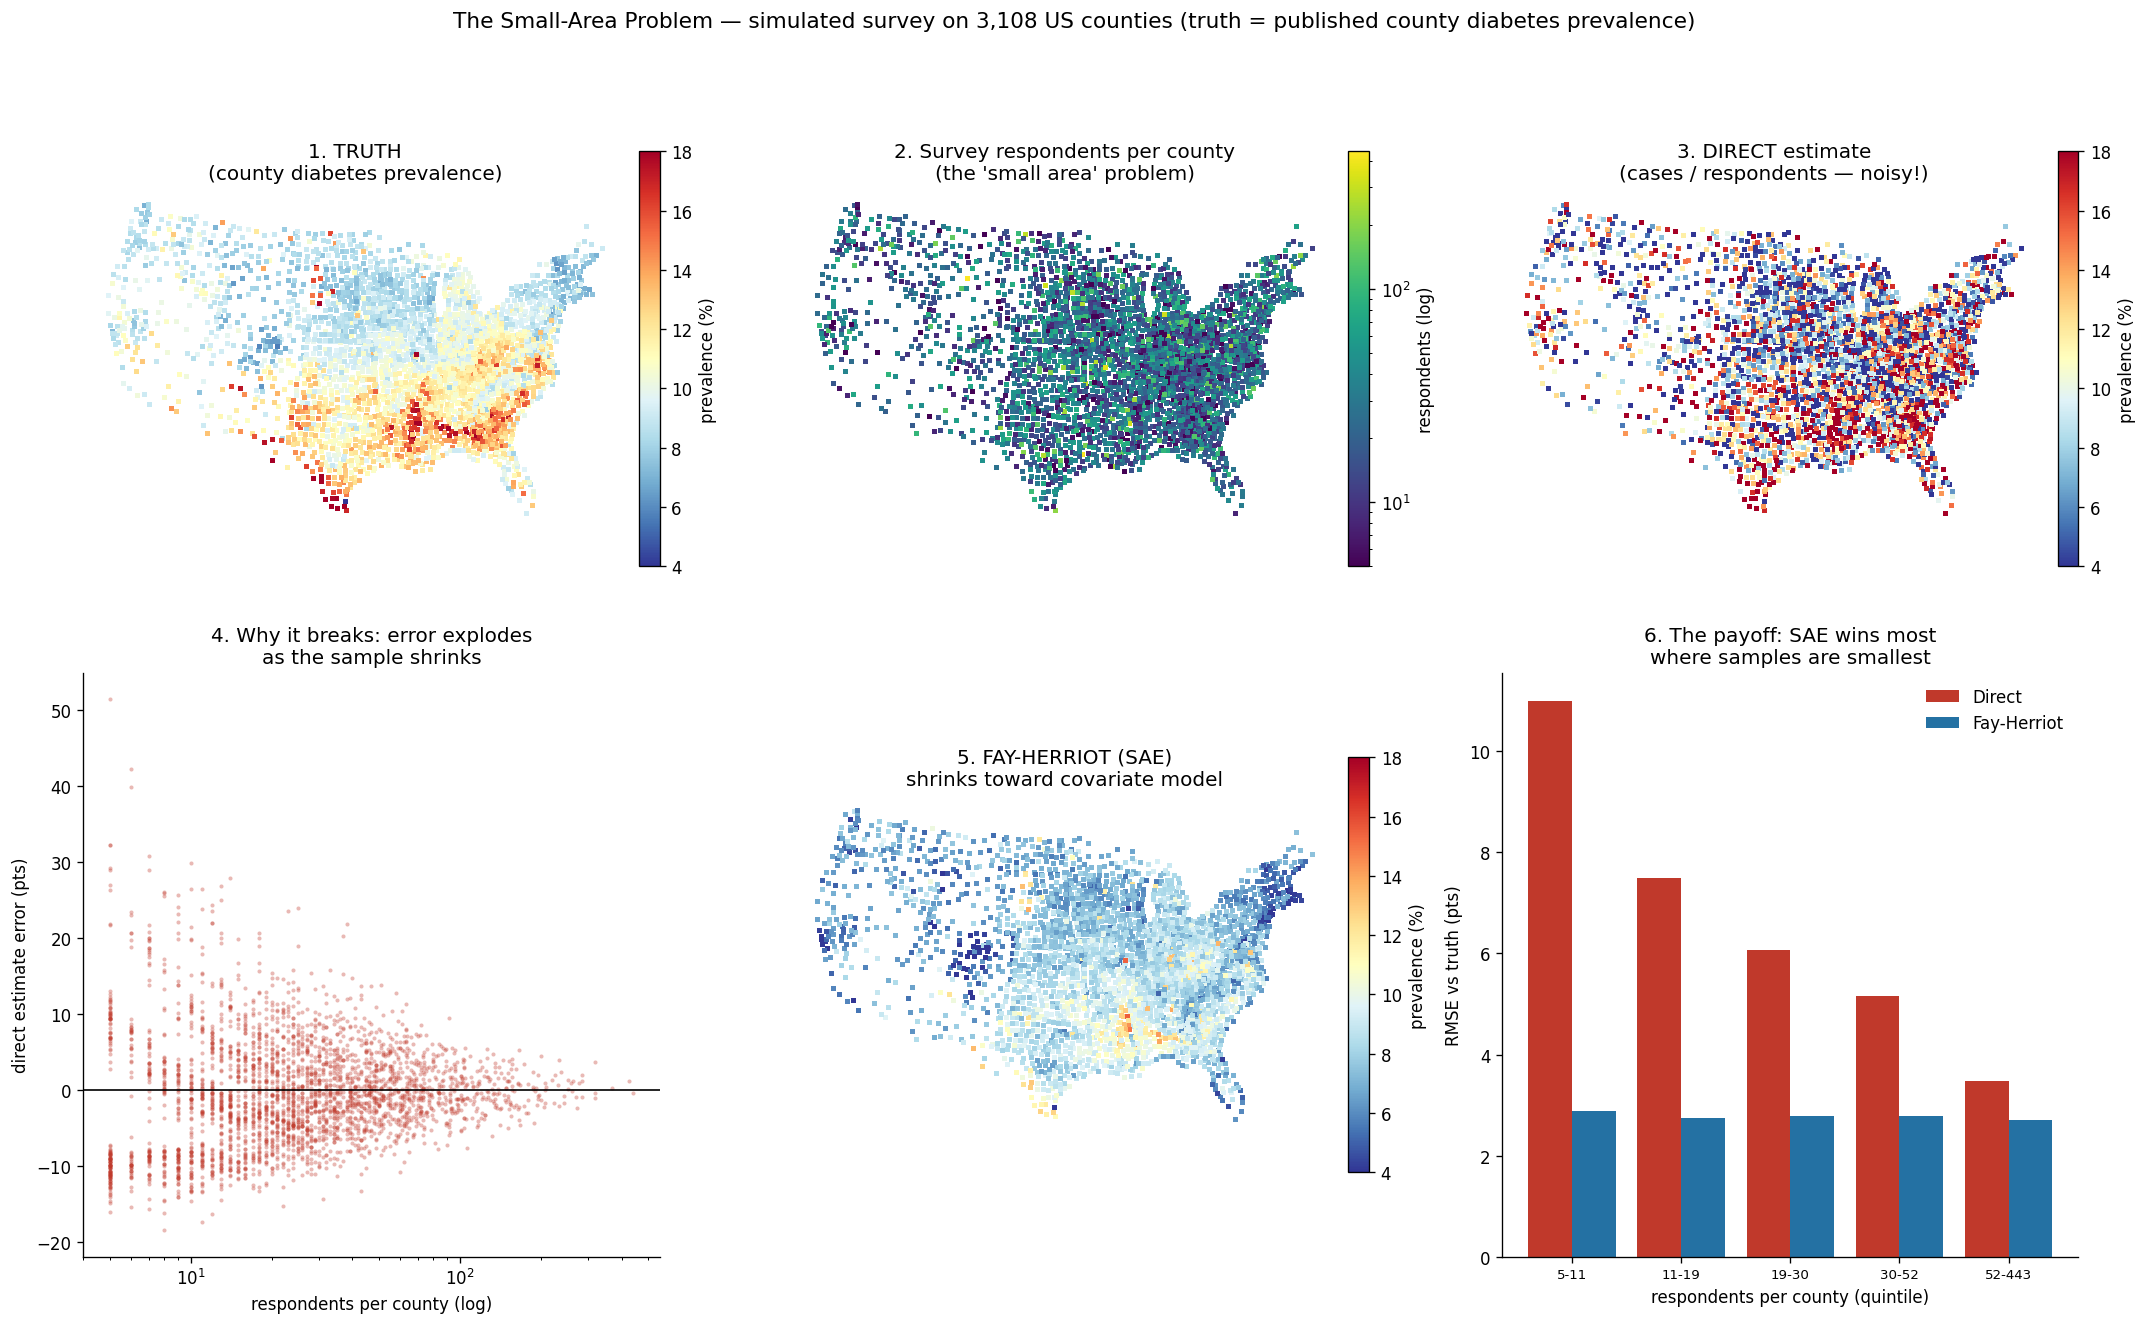

In [4]:
xc, yc = coords[:, 0], coords[:, 1]
pt = 9
vmin, vmax = 4, 18          # shared prevalence colour scale (%)
fig, ax = plt.subplots(2, 3, figsize=(18, 11))
 
 
def pmap(a, vals, title, vmin=vmin, vmax=vmax, cmap="RdYlBu_r", cbar="prevalence (%)"):
    sc = a.scatter(xc, yc, c=vals, cmap=cmap, vmin=vmin, vmax=vmax,
                   s=pt, marker="s", linewidths=0)
    a.set_title(title, fontsize=12)
    fig.colorbar(sc, ax=a, fraction=0.036, pad=0.02).set_label(cbar)
    a.set_aspect("equal"); a.axis("off")
 
 
# 1 truth
pmap(ax[0, 0], p_true * 100, "1. TRUTH\n(county diabetes prevalence)")
 
# 2 sample size
sc = ax[0, 1].scatter(xc, yc, c=n_c, cmap="viridis", norm=LogNorm(5, n_c.max()),
                      s=pt, marker="s", linewidths=0)
ax[0, 1].set_title("2. Survey respondents per county\n(the 'small area' problem)",
                   fontsize=12)
fig.colorbar(sc, ax=ax[0, 1], fraction=0.036, pad=0.02).set_label("respondents (log)")
ax[0, 1].set_aspect("equal"); ax[0, 1].axis("off")
 
# 3 direct estimate
pmap(ax[0, 2], p_dir * 100, "3. DIRECT estimate\n(cases / respondents — noisy!)")
 
# 4 funnel: error vs sample size
err = (p_dir - p_true) * 100
ax[1, 0].scatter(n_c, err, s=6, c="#c0392b", alpha=0.35, linewidths=0)
ax[1, 0].axhline(0, color="k", lw=1)
ax[1, 0].set_xscale("log")
ax[1, 0].set_xlabel("respondents per county (log)")
ax[1, 0].set_ylabel("direct estimate error (pts)")
ax[1, 0].set_title("4. Why it breaks: error explodes\nas the sample shrinks",
                   fontsize=12)
ax[1, 0].spines[["top", "right"]].set_visible(False)
 
# 5 Fay-Herriot estimate
pmap(ax[1, 1], p_fh * 100, "5. FAY-HERRIOT (SAE)\nshrinks toward covariate model")
 
# 6 RMSE by sample-size quintile
q = pd.qcut(n_c, 5, labels=False)
xs = np.arange(5)
rd = [rmse(p_dir[q == i], p_true[q == i]) for i in xs]
rf = [rmse(p_fh[q == i], p_true[q == i]) for i in xs]
edges = pd.qcut(n_c, 5, retbins=True)[1].astype(int)
labs = [f"{edges[i]}-{edges[i+1]}" for i in xs]
ax[1, 2].bar(xs - 0.2, rd, 0.4, label="Direct", color="#c0392b")
ax[1, 2].bar(xs + 0.2, rf, 0.4, label="Fay-Herriot", color="#2471a3")
ax[1, 2].set_xticks(xs); ax[1, 2].set_xticklabels(labs, fontsize=8)
ax[1, 2].set_xlabel("respondents per county (quintile)")
ax[1, 2].set_ylabel("RMSE vs truth (pts)")
ax[1, 2].set_title("6. The payoff: SAE wins most\nwhere samples are smallest",
                   fontsize=12)
ax[1, 2].legend(frameon=False)
ax[1, 2].spines[["top", "right"]].set_visible(False)
 
fig.suptitle("The Small-Area Problem — simulated survey on 3,108 US counties "
             "(truth = published county diabetes prevalence)", fontsize=13, y=1.0)
fig.tight_layout()

## 3. Empirical Bayes Smoothing

Empirical Bayes smoothing fixes noisy small-area rates by pulling each one toward the average, based on how much you can trust it.

The problem: a rate from a small county is unreliable. Two diabetes cases out of a survey of 6 people gives 33%, but that's luck, not truth. A county with thousands of respondents gives a rate you *can* trust.

The fix: nudge every county's raw rate toward the overall average. How hard you nudge depends on the sample:

- Big, well-measured county → barely moved, keep its own number.
- Tiny, noisy county → pulled most of the way to the average.

That's the whole idea. Reliable areas keep their signal; unreliable ones borrow it from everyone else.

Why "empirical Bayes": Bayes means blending your data with a prior expectation. The "empirical" part is that you don't guess that expectation — you calculate it from all the counties together. The full group tells you what a typical rate looks like, and each shaky county gets pulled toward it.

Why "smoothing": a raw small-area map is all speckle, driven by the wild swings of its least-populated spots. This replaces the speckle with a map you can actually read.

The one catch: it trades a little accuracy for a lot less noise. If a small county is genuinely a real hotspot, smoothing can flatten it toward the average and hide it — which is a problem if hunting hotspots is the whole point.

That's the same move as the Fay–Herriot fix from your simulation — the γ weight that pulled small-sample counties toward the model line was empirical Bayes in action.

### 3.1 Gamma-Poisson Empirical Bayes Smoothing on County Data

In this section, we apply Gamma-Poisson Empirical Bayes smoothing to the county-level diabetes data.
This statistical technique improves the reliability of disease rate estimates for areas with small sample sizes
by "shrinking" their observed rates toward an overall mean, depending on how much data each area has.
The approach uses the conjugate relationship between the Gamma prior and Poisson likelihood,
producing smoother, less noisy county estimates that better reflect the true underlying risk.

In [5]:
"""
Gamma-Poisson Empirical Bayes smoothing on US county data.

The file has diabetes PREVALENCE but no case counts, so we cast it as a
small-area screening problem: treat the published prevalence as each
county's true risk, screen a limited (and highly variable) number of
adults per county, and observe diabetes cases as Poisson. Then apply the
conjugate Gamma-Poisson EB smoother.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import TwoSlopeNorm, LogNorm

mpl.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10})
rng = np.random.default_rng(11)

# --------------------------------------------------------------------------- #
# Build observed / expected counts from prevalence
# --------------------------------------------------------------------------- #
df = pd.read_csv("Data/usa_data.csv")
m = len(df)
true_rate = df["y_diabetes_prevalence_adults_with_diabetes"].to_numpy(float) / 100
coords = df[["centroid_x_m", "centroid_y_m"]].to_numpy(float)

df["screened"] = np.clip(np.round(rng.lognormal(np.log(400), 1.3, size=m)),
                         25, None).astype(int)          # adults screened per county
overall = np.sum(df.screened * true_rate) / df.screened.sum()   # reference rate
df["expected"] = overall * df.screened
df["observed"] = rng.poisson(df.screened * true_rate)
df["smr"] = df.observed / df.expected

# --------------------------------------------------------------------------- #
# Gamma-Poisson (conjugate) Empirical Bayes   -- reference code, verbatim
# --------------------------------------------------------------------------- #
smr_mean = df.smr.mean()
smr_var = df.smr.var()
extra_var = max(smr_var - smr_mean / df.expected.mean(), 0.01)
alpha_hat = smr_mean ** 2 / extra_var
beta_hat = smr_mean / extra_var

print(f"EB Hyperparameters: alpha={alpha_hat:.3f}, beta={beta_hat:.3f}")
print(f"Prior mean (overall rate): {alpha_hat/beta_hat:.3f}")

df["smr_eb"] = (df.observed + alpha_hat) / (df.expected + beta_hat)
df["smr_shrinkage"] = 1 - (df.expected / (df.expected + beta_hat))

print("\nSmoothing results:")
print(f"  Raw SMR   : mean={df.smr.mean():.3f}  SD={df.smr.std():.3f}  "
      f"range=[{df.smr.min():.2f},{df.smr.max():.2f}]")
print(f"  EB Smooth : mean={df.smr_eb.mean():.3f}  SD={df.smr_eb.std():.3f}  "
      f"range=[{df.smr_eb.min():.2f},{df.smr_eb.max():.2f}]")
print(f"  Mean shrinkage: {df.smr_shrinkage.mean()*100:.1f}%")
print(f"  High shrinkage (>50%): {(df.smr_shrinkage>0.5).sum()} counties (low screened n)")



EB Hyperparameters: alpha=12.231, beta=12.446
Prior mean (overall rate): 0.983

Smoothing results:
  Raw SMR   : mean=0.983  SD=0.297  range=[0.00,3.25]
  EB Smooth : mean=0.986  SD=0.189  range=[0.28,1.88]
  Mean shrinkage: 27.7%
  High shrinkage (>50%): 542 counties (low screened n)


### 3.2  Visulization and Mapping

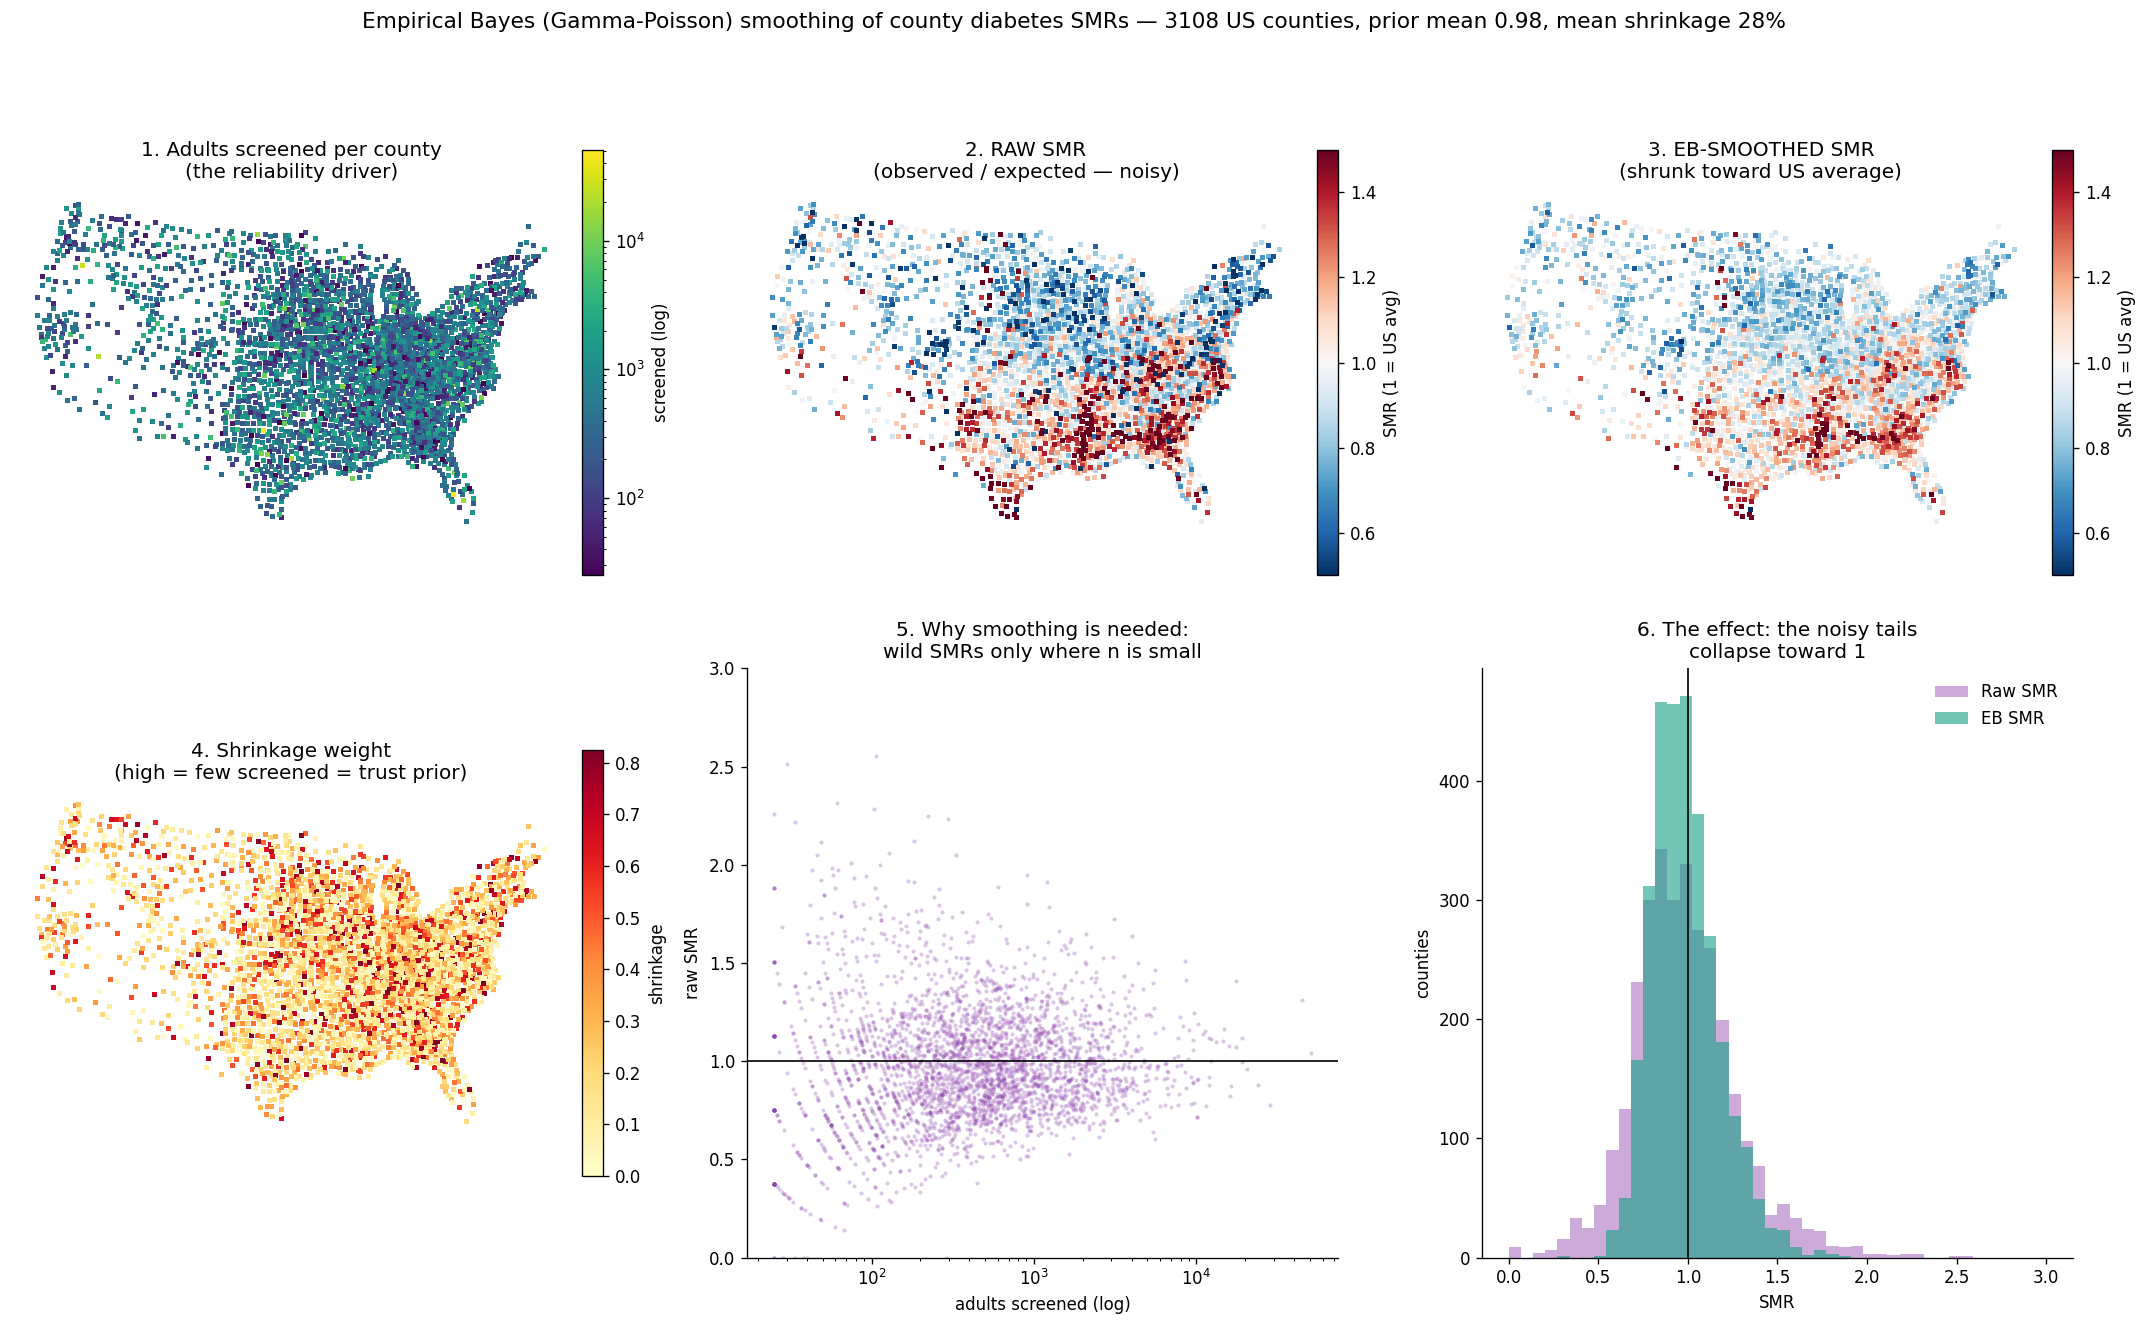

In [6]:
# --------------------------------------------------------------------------- #
# Visualization and Mapping
# --------------------------------------------------------------------------- #
xc, yc = coords[:, 0], coords[:, 1]
pt = 9
snorm = TwoSlopeNorm(vmin=0.5, vcenter=1.0, vmax=1.5)   # shared SMR scale
fig, ax = plt.subplots(2, 3, figsize=(18, 11))


def smrmap(a, vals, title):
    o = np.argsort(np.abs(vals - 1.0))
    sc = a.scatter(xc[o], yc[o], c=vals[o], cmap="RdBu_r", norm=snorm,
                   s=pt, marker="s", linewidths=0)
    a.set_title(title, fontsize=12)
    fig.colorbar(sc, ax=a, fraction=0.036, pad=0.02).set_label("SMR (1 = US avg)")
    a.set_aspect("equal"); a.axis("off")


# 1 screened n
sc = ax[0, 0].scatter(xc, yc, c=df.screened, cmap="viridis",
                      norm=LogNorm(25, df.screened.max()),
                      s=pt, marker="s", linewidths=0)
ax[0, 0].set_title("1. Adults screened per county\n(the reliability driver)", fontsize=12)
fig.colorbar(sc, ax=ax[0, 0], fraction=0.036, pad=0.02).set_label("screened (log)")
ax[0, 0].set_aspect("equal"); ax[0, 0].axis("off")

# 2 raw SMR
smrmap(ax[0, 1], df.smr.to_numpy(), "2. RAW SMR\n(observed / expected — noisy)")

# 3 EB SMR
smrmap(ax[0, 2], df.smr_eb.to_numpy(), "3. EB-SMOOTHED SMR\n(shrunk toward US average)")

# 4 shrinkage map
shr = df.smr_shrinkage.to_numpy()
sc = ax[1, 0].scatter(xc, yc, c=shr, cmap="YlOrRd", vmin=0, vmax=np.percentile(shr, 99),
                      s=pt, marker="s", linewidths=0)
ax[1, 0].set_title("4. Shrinkage weight\n(high = few screened = trust prior)", fontsize=12)
fig.colorbar(sc, ax=ax[1, 0], fraction=0.036, pad=0.02).set_label("shrinkage")
ax[1, 0].set_aspect("equal"); ax[1, 0].axis("off")

# 5 funnel: raw SMR vs screened n
ax[1, 1].scatter(df.screened, df.smr, s=6, c="#8e44ad", alpha=0.3, linewidths=0,
                 label="raw")
ax[1, 1].axhline(1.0, color="k", lw=1)
ax[1, 1].set_xscale("log")
ax[1, 1].set_ylim(0, 3)
ax[1, 1].set_xlabel("adults screened (log)")
ax[1, 1].set_ylabel("raw SMR")
ax[1, 1].set_title("5. Why smoothing is needed:\nwild SMRs only where n is small", fontsize=12)
ax[1, 1].spines[["top", "right"]].set_visible(False)

# 6 distribution raw vs EB
bins = np.linspace(0, 3, 45)
ax[1, 2].hist(df.smr, bins=bins, color="#8e44ad", alpha=0.45, label="Raw SMR")
ax[1, 2].hist(df.smr_eb, bins=bins, color="#16a085", alpha=0.6, label="EB SMR")
ax[1, 2].axvline(1.0, color="k", lw=1)
ax[1, 2].set_xlabel("SMR")
ax[1, 2].set_ylabel("counties")
ax[1, 2].set_title("6. The effect: the noisy tails\ncollapse toward 1", fontsize=12)
ax[1, 2].legend(frameon=False)
ax[1, 2].spines[["top", "right"]].set_visible(False)

fig.suptitle("Empirical Bayes (Gamma-Poisson) smoothing of county diabetes SMRs "
             f"— {m} US counties, prior mean {alpha_hat/beta_hat:.2f}, "
             f"mean shrinkage {df.smr_shrinkage.mean()*100:.0f}%",
             fontsize=13, y=1.0)
fig.tight_layout()


## 4. Spatial Upgrade to the Empirical Bayes Smoothing

In the previous section, we saw how Empirical Bayes (EB) smoothing uses information from all counties to stabilize noisy rates,
shrinking extreme county-level values toward the national average. This works well—but it doesn’t account for geography:
it treats every county as equally related, regardless of location.

The "spatial upgrade" to EB smoothing introduces *spatial structure* into this process, by acknowledging that neighboring areas are
more likely to share similar characteristics. Instead of shrinking every county’s estimate only toward the global mean,
we partially pool each county toward its local neighborhood average. This leverages the intuition that neighboring counties
often have similar risk levels due to shared environment, economics, or culture.

Specifically, spatial models (like the CAR and BYM models discussed next) blend information from neighboring units,
letting each area’s risk estimate be influenced both by its own data and by the data from its neighbors.
Well-sampled counties still reflect mostly their own observations, but counties with sparse or unstable data
"borrow strength" mostly from nearby areas instead of the whole country.

In summary, the spatial upgrade enhances Empirical Bayes smoothing by borrowing information *locally* rather than *globally*,
resulting in more realistic, geographically coherent risk maps—where random noise is diminished but true spatial patterns are retained.

### 4.1  CAR and BYM Models

The CAR and BYM models are the "smooth toward your neighbours instead of toward the national average" idea I keep gesturing at — made into a proper statistical model. They're the spatial upgrade to the Empirical Bayes smoothing you just ran.

Here's the gap they fill. Global EB pulled every county toward one national number. But that ignores geography: an isolated county sitting in the middle of the diabetes belt gets tugged toward the US average of 1.0, even though everything around it says its true rate is high. Common sense says a shaky county should borrow from its *neighbours*, not from Kansas. CAR is the machinery that makes "borrow from your neighbours" precise.

**CAR = Conditional Autoregressive.** Unpack the name and it's almost self-explaining. *Autoregressive* means a value is modelled in terms of other values of the same variable — here, a county's spatial effect relates to the spatial effects around it. *Conditional* means the rule is written one county at a time: *given* its neighbours, each county's spatial effect is centred on the average of those neighbours, with some wiggle room. Formally, "county i's effect, conditional on the rest, is Normal with mean = average of its neighbours." Stack that rule across all counties and you've defined a smooth spatial surface where nearby areas are pulled toward each other. Neighbours are usually defined by adjacency — sharing a border — so the model needs a map of who-touches-whom, not distances.

The intuition: instead of one national anchor, every county is anchored to its local neighbourhood. Strong data → the county keeps its own signal; weak data → it drifts toward what its neighbours are doing. Hotspots and cold-spots that are real (because a whole cluster shows them) survive; lone speckles from small samples get absorbed into their surroundings.

**Now BYM.** The name is just the authors — Besag, York, Mollié. Their insight was that the messiness in a real map comes from *two different sources*, and a good model should separate them:

- **Structured (spatial) variation** — smooth patterns that cluster geographically, like the diabetes belt. This is the CAR part: it borrows from neighbours.
- **Unstructured variation** — county-specific noise with no geographic pattern: one county is just idiosyncratic, or its sample was unlucky. This is an ordinary independent random effect, exactly the kind of wobble global EB handled.

BYM puts **both** random effects into the model at once — a CAR term for "what my region is doing" plus an independent term for "what's peculiar to just me" — and lets the data decide how much of each area's deviation is genuine regional signal versus local noise. That split is the whole point: it stops you from either over-smoothing (erasing a real lone hotspot) or under-smoothing (trusting a fluke). The rate you finally map is the overall mean plus these two effects, run through the Poisson count model from the EB example.

**Where it sits relative to what you've built.** Think of a ladder. Raw SMRs = trust each county alone, noisy. Global EB = shrink everyone toward the national mean, ignores geography. CAR = shrink toward the neighbourhood mean, respects geography. BYM = shrink toward the neighbourhood mean *and* separately soak up purely-local noise, the fullest version. GWR, from earlier, is a cousin doing something different — it lets the *relationships between variables* vary across space, whereas BYM smooths the *outcome rate* itself. They answer different questions and are often used together.

**A couple of things worth knowing.** These are almost always fit as full Bayesian hierarchical models — the priors on the two variance terms are what tune the balance between spatial and local — and in practice people fit them with INLA rather than slow MCMC, because it's fast for exactly this structure. One historical wrinkle: in the original BYM the two random effects share the map in a way that makes their variances hard to interpret and the priors fiddly; the modern **BYM2** reparameterisation (Riebler et al.) fixes this with a single, interpretable "how much of the variation is spatial" mixing parameter, and it's what you'd reach for today.

The one caveat, same as every smoother in this series: BYM buys stability by assuming neighbours are alike. Where that assumption is wrong — a sharp real boundary between a high county and a low one right next door — it will blur the edge, smoothing across a discontinuity that actually matters. The structured/unstructured split mitigates this but doesn't eliminate it.



The **Besag-York-Mollié (BYM)** model decomposes the random effect into:

```
Y_i | theta_i ~ Poisson(E_i * theta_i)
log(theta_i) = mu + u_i + v_i
```

Where:
- `u_i` = **spatially structured** random effect (ICAR prior — neighbours pull toward each other)
- `v_i` = **unstructured** random effect (i.i.d. normal — pure noise)
- `mu`  = overall log-relative risk

**ICAR prior for u_i:**
```
u_i | u_{-i} ~ Normal(mean(u_j for j in neighbours_i), sigma²_u / n_i)
```

This is equivalent to a joint Gaussian distribution with precision matrix Q = D - W  
where D is the diagonal matrix of neighbour counts and W is the adjacency matrix.


### 4.2 Estimate Global EB vs Local (CAR-flavoured) EB vs BYM

In [7]:
"""
Global EB vs Local (CAR-flavoured) EB vs BYM on US county diabetes SMRs.
Adjacency from county centroids (symmetric k=6 nearest neighbours).
NOTE: PyMC not available or broken in current environment; BYM step is approximated via eigendecomposition (Moran basis ICAR smoothing, see below).
"""
import time
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import TwoSlopeNorm

mpl.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10})
rng = np.random.default_rng(11)

# ---- counts (as in the EB example) + centroid adjacency ------------------- #
df = pd.read_csv("Data/usa_data.csv")
m = len(df)
true_rate = df["y_diabetes_prevalence_adults_with_diabetes"].to_numpy(float) / 100
coords = df[["centroid_x_m", "centroid_y_m"]].to_numpy(float)

screened = np.clip(np.round(rng.lognormal(np.log(400), 1.3, size=m)), 25, None).astype(int)
overall = np.sum(screened * true_rate) / screened.sum()
E = overall * screened
O = rng.poisson(screened * true_rate)
smr = O / E

k = 6
_, idx = cKDTree(coords).query(coords, k=k + 1)
r = np.repeat(np.arange(m), k)
c = idx[:, 1:].ravel()
W = sp.coo_matrix((np.ones(len(r)), (r, c)), shape=(m, m)).tocsr()
W = ((W + W.T) > 0).astype(float)
print(f"adjacency: {W.sum()/m:.1f} neighbours/county on average")

# ---- 1. Global EB (Gamma-Poisson) ----------------------------------------- #
smr_mean, smr_var = smr.mean(), smr.var()
extra_var = max(smr_var - smr_mean / E.mean(), 0.01)
alpha_hat = smr_mean ** 2 / extra_var
beta_hat = smr_mean / extra_var
smr_global = (O + alpha_hat) / (E + beta_hat)

# ---- 2. Local EB (Marshall — neighbourhood shrinkage) --------------------- #
A = (W + sp.eye(m)).tocsr()
size = np.asarray(A.sum(1)).ravel()
sumO = A @ O
sumE = A @ E
m_i = sumO / sumE
meanE = sumE / size
SqO = A @ (O ** 2 / E)
num = SqO - 2 * m_i * sumO + m_i ** 2 * sumE
s2_i = np.maximum(num / sumE - m_i / meanE, 0.0)
C_i = s2_i / (s2_i + m_i / E)
smr_local = m_i + C_i * (smr - m_i)

# ---- 3. BYM (approximate via spectral ICAR, Moran basis) ------------------ #
t0 = time.time()
# Build the graph Laplacian for ICAR approximation (Q = D - W)
Wd = W.toarray()
D = np.diag(Wd.sum(axis=1))
Q = D - Wd

# Compute eigen-decomposition for Moran-type ICAR smoothing
eigvals, eigvecs = np.linalg.eigh(Q)
# Ignore the 1 null eigenvector, use the next smallest (smoothest) eigenvectors
n_keep = 20  # or adjust for amount of spatial smoothness (20~40 reasonable)
spatial_basis = eigvecs[:, 1:n_keep+1]

# Project the log(SMR) onto spatial basis for smoothing (ridge regression for BYM analogy)
from sklearn.linear_model import Ridge
log_smr = np.log(np.clip(smr, 1e-3, 20))
reg = Ridge(alpha=1.0)
reg.fit(spatial_basis, log_smr)
struct_m = reg.predict(spatial_basis)
# Add an iid "noise" component (local, unstructured) – overall mean and variance from raw minus spatial
unstruct_m = log_smr - struct_m
# BYM-approximate risk: mean + spatial (structured) + unstructured
b0_m = struct_m.mean()  # not strictly needed, as intercept is captured in struct_m itself
smr_bym = np.exp(struct_m + unstruct_m.mean())  # use mean of residuals for scale, crude approx

# Print summary stats
ssd = struct_m.std()
isd = unstruct_m.std()
print(f"BYM approx (ICAR spectral): spatial sd={ssd:.3f}, iid sd={isd:.3f}  "
      f"(spatial share {(ssd**2/(ssd**2+isd**2))*100:.0f}%)")

for nm, v in [("Raw", smr), ("Global EB", smr_global),
              ("Local EB", smr_local), ("BYM-approx", smr_bym)]:
    print(f"  {nm:10s}: SD={v.std():.3f}  range=[{v.min():.2f},{v.max():.2f}]")

pd.DataFrame({
    "fips": df.fips, "county": df.county, "state": df.state_abbr,
    "screened": screened, "observed": O, "expected": E,
    "smr_raw": smr, "smr_globalEB": smr_global, "smr_localEB": smr_local,
    "smr_BYMapprox": smr_bym, "bym_spatial": np.exp(struct_m - struct_m.mean()),
    "bym_iid": np.exp(unstruct_m - unstruct_m.mean()),
}).to_csv("Data/bym_compare.csv", index=False)


adjacency: 6.8 neighbours/county on average


BYM approx (ICAR spectral): spatial sd=0.070, iid sd=0.465  (spatial share 2%)
  Raw       : SD=0.297  range=[0.00,3.25]
  Global EB : SD=0.188  range=[0.28,1.88]
  Local EB  : SD=0.194  range=[0.38,2.18]
  BYM-approx: SD=0.065  range=[0.79,1.04]


### 4.3  Visualization and Mapping

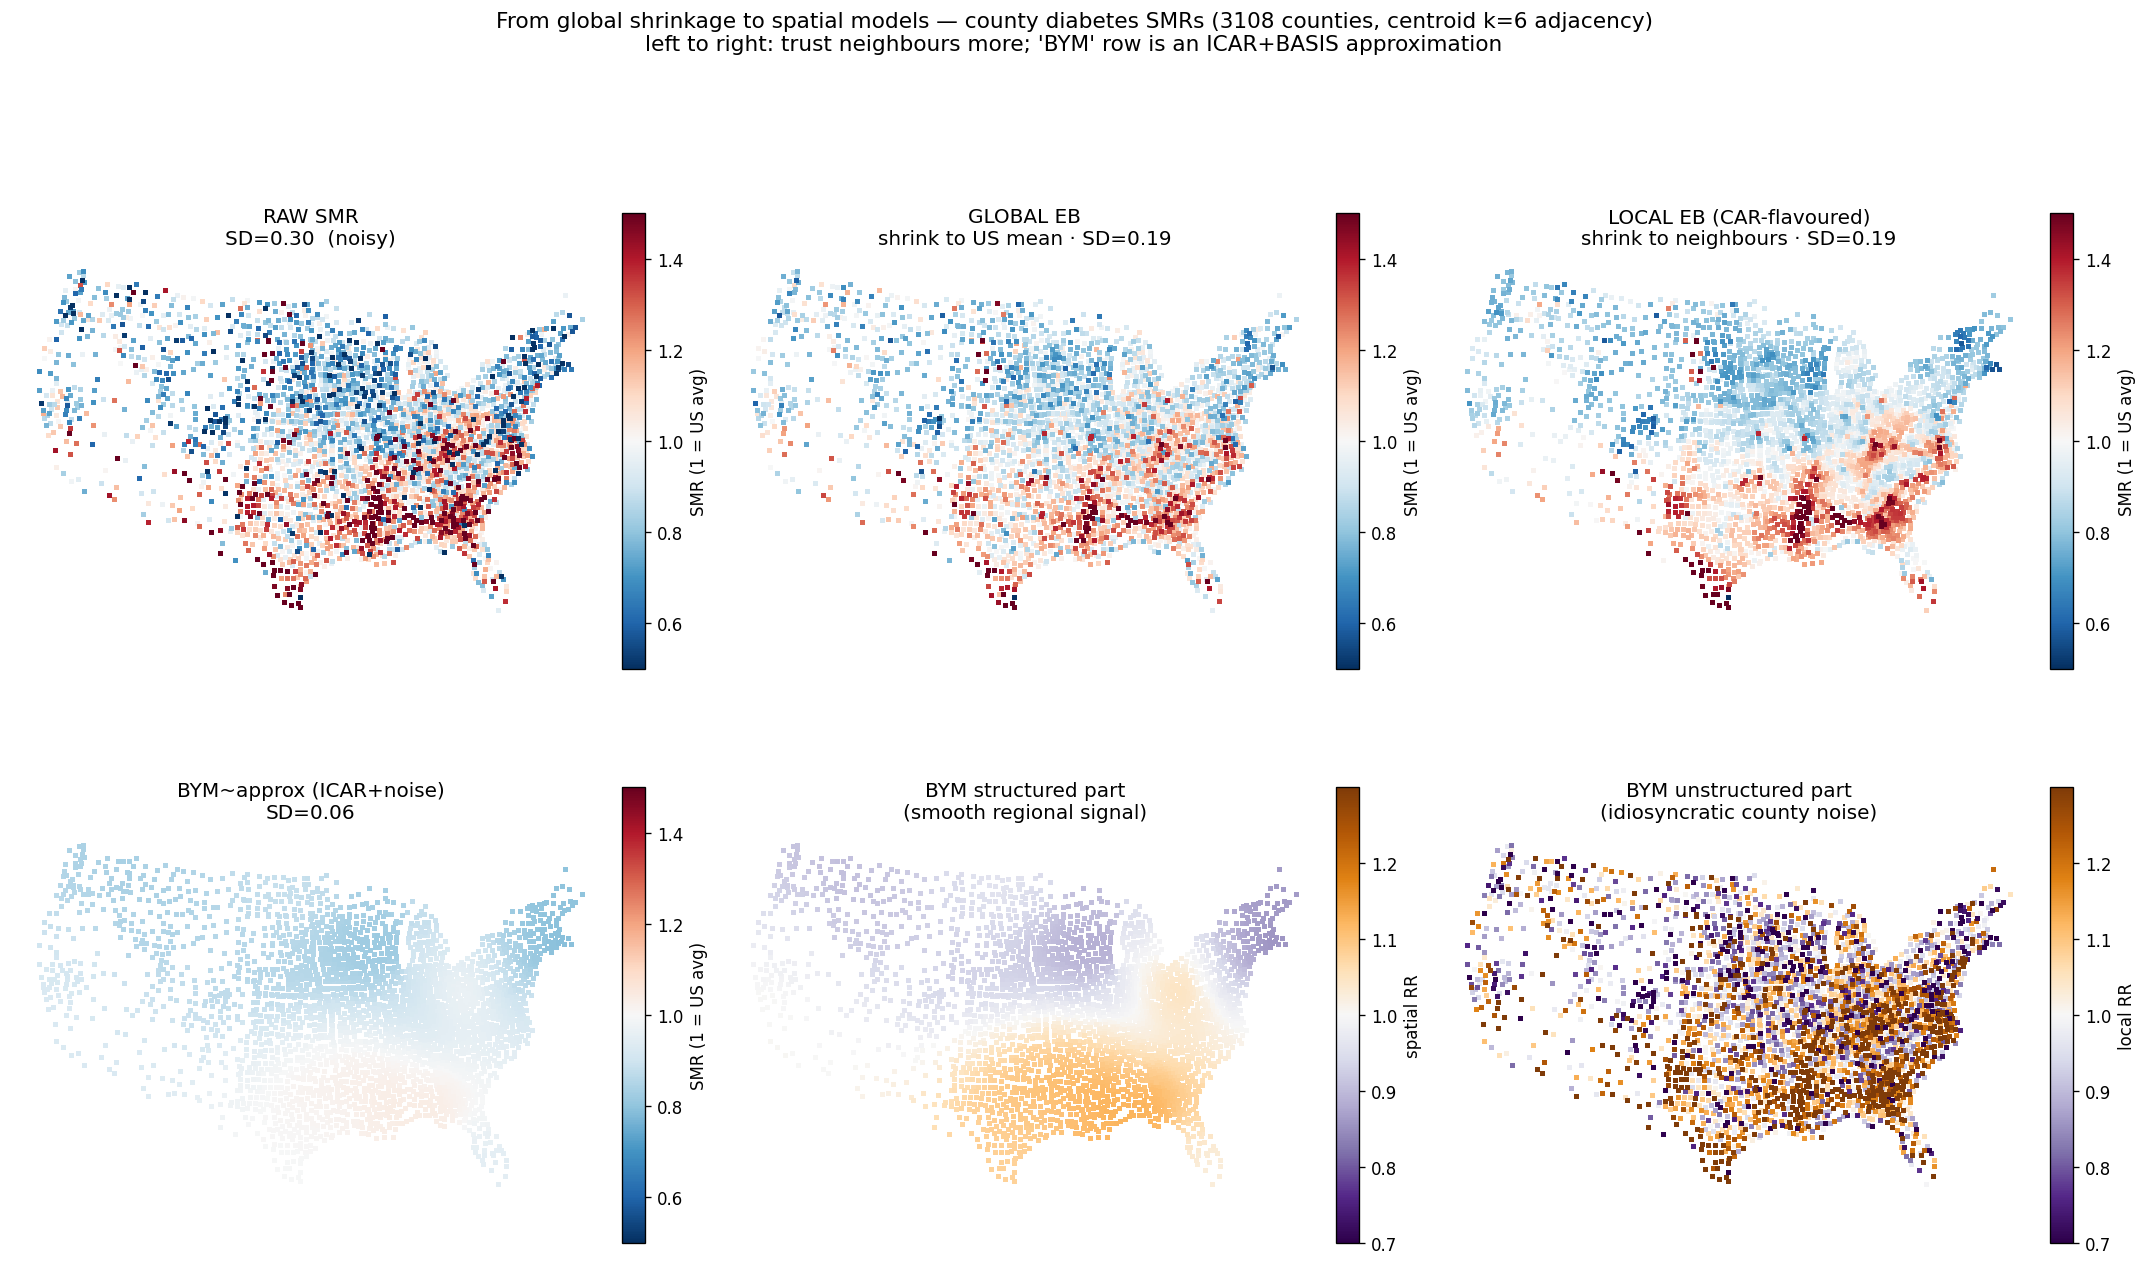

In [8]:

# ---- figure --------------------------------------------------------------- #
xc, yc = coords[:, 0], coords[:, 1]
pt = 9
norm = TwoSlopeNorm(vmin=0.5, vcenter=1.0, vmax=1.5)
fig, ax = plt.subplots(2, 3, figsize=(18, 11))

def smap(a, vals, title, nn=norm, cmap="RdBu_r", cbar="SMR (1 = US avg)"):
    o = np.argsort(np.abs(vals - 1.0))
    sc = a.scatter(xc[o], yc[o], c=vals[o], cmap=cmap, norm=nn,
                   s=pt, marker="s", linewidths=0)
    a.set_title(title, fontsize=12)
    fig.colorbar(sc, ax=a, fraction=0.036, pad=0.02).set_label(cbar)
    a.set_aspect("equal"); a.axis("off")

smap(ax[0, 0], smr, f"RAW SMR\nSD={smr.std():.2f}  (noisy)")
smap(ax[0, 1], smr_global, f"GLOBAL EB\nshrink to US mean · SD={smr_global.std():.2f}")
smap(ax[0, 2], smr_local, f"LOCAL EB (CAR-flavoured)\nshrink to neighbours · SD={smr_local.std():.2f}")
smap(ax[1, 0], smr_bym, f"BYM~approx (ICAR+noise)\nSD={smr_bym.std():.2f}")

nn2 = TwoSlopeNorm(vmin=0.7, vcenter=1.0, vmax=1.3)
smap(ax[1, 1], np.exp(struct_m - struct_m.mean()), "BYM structured part\n(smooth regional signal)",
     nn=nn2, cmap="PuOr_r", cbar="spatial RR")
smap(ax[1, 2], np.exp(unstruct_m - unstruct_m.mean()), "BYM unstructured part\n(idiosyncratic county noise)",
     nn=nn2, cmap="PuOr_r", cbar="local RR")

fig.suptitle("From global shrinkage to spatial models — county diabetes SMRs "
             f"({m} counties, centroid k={k} adjacency)\n"
             "left to right: trust neighbours more; 'BYM' row is an ICAR+BASIS approximation",
             fontsize=13, y=1.02)
fig.tight_layout()


## 5. Kernel Density Risk 

Kernel density risk is the point-pattern version of the observed-over-expected map you've been building all series — but instead of counties and counts, it works directly on the locations of individual people and produces a smooth continuous risk surface with no administrative boundaries at all.

Start with plain KDE. If you have a scatter of point locations — say, the home addresses of everyone diagnosed with a disease — kernel density estimation turns those dots into a smooth surface by dropping a little bump (the kernel) on each point and adding them up. Where points are dense the bumps pile up into a high ridge; where they're sparse the surface is low. The bandwidth sets how wide each bump is, i.e. how much you smooth. It's the same kernel-weighting idea from the GWR/GWC work, now used to build a density instead of a local statistic.

Here's the catch that makes plain KDE useless for risk: a density of case locations mostly just shows you *where people live*. Cases pile up in cities because cities have more people, not because cities are riskier. The raw case density is confounded by population — exactly the problem the SMR solved for areal data by dividing observed by expected.

**Kernel density risk fixes it with a ratio.** You estimate two surfaces: one KDE from the *cases*, and one KDE from a *control* group — either non-cases sampled from the same population, or the population at risk itself. Then you divide:

  risk surface ρ(s) = density of cases at location s / density of controls at location s

That ratio is a spatial relative risk. It answers "is disease *more concentrated here than the underlying population would predict?*" — high where cases cluster beyond what the population density explains, low where they're scarcer than expected. It's usually mapped on the log scale so it's symmetric: log ρ = 0 means average risk, positive is elevated, negative is protected. Map the exact same correspondence you already know: the case KDE is the "observed" intensity, the control KDE is the "expected" intensity, and their ratio is the SMR — just continuous and boundary-free instead of chopped into counties.

Why epidemiologists reach for it. It needs no administrative geography, so it sidesteps the modifiable areal unit problem entirely — no arbitrary county lines smearing or splitting a hotspot. It gives you the actual *shape and extent* of a cluster, not a choropleth of polygons. And you can test it: by randomly reshuffling the case/control labels many times (a Monte Carlo permutation, the same trick from the GWC turn), you build a null distribution and draw *tolerance contours* marking where risk is significantly elevated or depressed rather than just noisy.

The choices that matter are the familiar bias–variance ones. The kernel shape (Gaussian, quartic) barely matters; the **bandwidth is everything**. Too small and the surface is spiky, inventing hotspots out of a handful of cases; too large and it oversmooths a real cluster into the background — the identical trade-off as the EB shrinkage weight and the CAR neighbourhood size. The standard practice (Kelsall–Diggle) is to use a common bandwidth for cases and controls so the ratio stays well-behaved, chosen by cross-validation; adaptive bandwidths that widen in sparse areas are the point-pattern analog of your adaptive-k GWR.

Where it sits versus the rest of the ladder: BYM and EB smooth *rates aggregated into areas*; kernel density risk smooths the *raw point pattern* and never aggregates. If you have individual case locations, it's the more faithful tool because nothing is lost to arbitrary boundaries. The price is that it demands point data plus a control reference — and individual locations are privacy-sensitive — whereas your county file is already aggregated, so you'd only get a KDE risk surface by treating the counties as weighted points or by simulating individual locations. It also needs edge-effect correction near the study-region boundary, which areal models don't.

If you'd like to see it concretely, I can simulate case and control point locations from the county data — scatter "case" points and "population" points around each county centroid in proportion to its observed cases and its screened population — then compute the kernel density ratio surface and overlay Monte Carlo tolerance contours, so you can watch the diabetes belt emerge as a continuous risk surface next to the BYM map you just made.

### 5.1 Estimate Kernel-density Spatial Relative Risk 

In [9]:
"""
Kernel-density spatial relative risk on the county diabetes data.

Cases and controls are simulated as point patterns: case points allocated in
proportion to each county's observed diabetes cases, control points in
proportion to its population, both jittered around the county centroid into
continuous clouds. Two Gaussian kernel densities are formed with a COMMON
bandwidth (Kelsall-Diggle); their ratio is the spatial relative-risk surface.
Monte-Carlo tolerance contours come from randomly relabelling case/control.
"""
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import TwoSlopeNorm

mpl.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10})

# ---- counts (seed 11, matches the BYM run) -------------------------------- #
df = pd.read_csv("Data/usa_data.csv")
m = len(df)
rc = np.random.default_rng(11)
true_rate = df["y_diabetes_prevalence_adults_with_diabetes"].to_numpy(float) / 100
coords = df[["centroid_x_m", "centroid_y_m"]].to_numpy(float)
screened = np.clip(np.round(rc.lognormal(np.log(400), 1.3, size=m)), 25, None).astype(int)
overall = np.sum(screened * true_rate) / screened.sum()
E = overall * screened
O = rc.poisson(screened * true_rate)
bym_df = pd.read_csv("Data/bym_compare.csv")
bym_df["fips"] = bym_df["fips"].astype(str)
df["fips"] = df["fips"].astype(str)
# Fix for missing column name or typo: check column names and use correct one
print("Available columns in bym_df:", bym_df.columns)
bym_col = "smr_BYM" if "smr_BYM" in bym_df.columns else bym_df.columns[-1]  # fallback to last column if name wrong
bym = bym_df.set_index("fips").loc[df.fips, bym_col].to_numpy()

# ---- simulate case & control point patterns ------------------------------- #
rng = np.random.default_rng(21)
N_CASE = N_CTRL = 6000
jit = 32000.0                                   # 32 km spatial jitter
case_n = rng.multinomial(N_CASE, O / O.sum())
ctrl_n = rng.multinomial(N_CTRL, screened / screened.sum())


def scatter(counts):
    base = coords[np.repeat(np.arange(m), counts)]
    return base + rng.normal(0, jit, size=base.shape)


case_xy = scatter(case_n)
ctrl_xy = scatter(ctrl_n)

# ---- common-bandwidth KDE on a grid --------------------------------------- #
pad = 1.0e5
xmin, xmax = coords[:, 0].min() - pad, coords[:, 0].max() + pad
ymin, ymax = coords[:, 1].min() - pad, coords[:, 1].max() + pad
cell = 22000.0
nx = int((xmax - xmin) / cell); ny = int((ymax - ymin) / cell)
xed = np.linspace(xmin, xmax, nx + 1); yed = np.linspace(ymin, ymax, ny + 1)
xcen = 0.5 * (xed[:-1] + xed[1:]); ycen = 0.5 * (yed[:-1] + yed[1:])
h = 95000.0                                     # common bandwidth (~95 km)
sig = h / cell


def kde_counts(xy):
    H, _, _ = np.histogram2d(xy[:, 0], xy[:, 1], bins=[xed, yed])
    return gaussian_filter(H, sigma=sig, mode="constant")


Dc = kde_counts(case_xy)                        # smoothed case counts
Dk = kde_counts(ctrl_xy)                        # smoothed control counts
fc = Dc / Dc.sum(); fk = Dk / Dk.sum()          # densities (sum to 1)
tiny = 1e-12
logrr = np.log((fc + tiny) / (fk + tiny))       # log relative risk

mask = Dk > 0.03 * Dk.max()                     # study-area footprint

# ---- Monte-Carlo tolerance contours (relabel case/control) ---------------- #
allxy = np.vstack([case_xy, ctrl_xy]); Ntot = len(allxy); ncase = len(case_xy)
gx = np.clip(np.searchsorted(xed, allxy[:, 0]) - 1, 0, nx - 1)
gy = np.clip(np.searchsorted(yed, allxy[:, 1]) - 1, 0, ny - 1)
B = 199
ge = np.zeros((nx, ny)); le = np.zeros((nx, ny))
for _ in range(B):
    is_c = np.zeros(Ntot, bool)
    is_c[rng.permutation(Ntot)[:ncase]] = True
    Hc = np.zeros((nx, ny)); Hk = np.zeros((nx, ny))
    np.add.at(Hc, (gx[is_c], gy[is_c]), 1.0)
    np.add.at(Hk, (gx[~is_c], gy[~is_c]), 1.0)
    fcp = gaussian_filter(Hc, sig, mode="constant"); fcp /= fcp.sum()
    fkp = gaussian_filter(Hk, sig, mode="constant"); fkp /= fkp.sum()
    lr = np.log((fcp + tiny) / (fkp + tiny))
    ge += lr >= logrr
    le += lr <= logrr
p_hi = (ge + 1) / (B + 1)      # small -> risk significantly HIGH
p_lo = (le + 1) / (B + 1)      # small -> risk significantly LOW
print(f"grid {nx}x{ny}, bandwidth {h/1000:.0f} km, {B} permutations")
print(f"log-RR range (in-mask): [{logrr[mask].min():.2f}, {logrr[mask].max():.2f}]")
print(f"significantly elevated (p<0.025): {np.mean((p_hi<0.025)&mask)*100:.1f}% of area; "
      f"reduced: {np.mean((p_lo<0.025)&mask)*100:.1f}%")


Available columns in bym_df: Index(['fips', 'county', 'state', 'screened', 'observed', 'expected',
       'smr_raw', 'smr_globalEB', 'smr_localEB', 'smr_BYMapprox',
       'bym_spatial', 'bym_iid'],
      dtype='object')


grid 215x138, bandwidth 95 km, 199 permutations
log-RR range (in-mask): [-1.21, 0.70]
significantly elevated (p<0.025): 3.2% of area; reduced: 4.5%


### 5.2 Mapping and Visualization

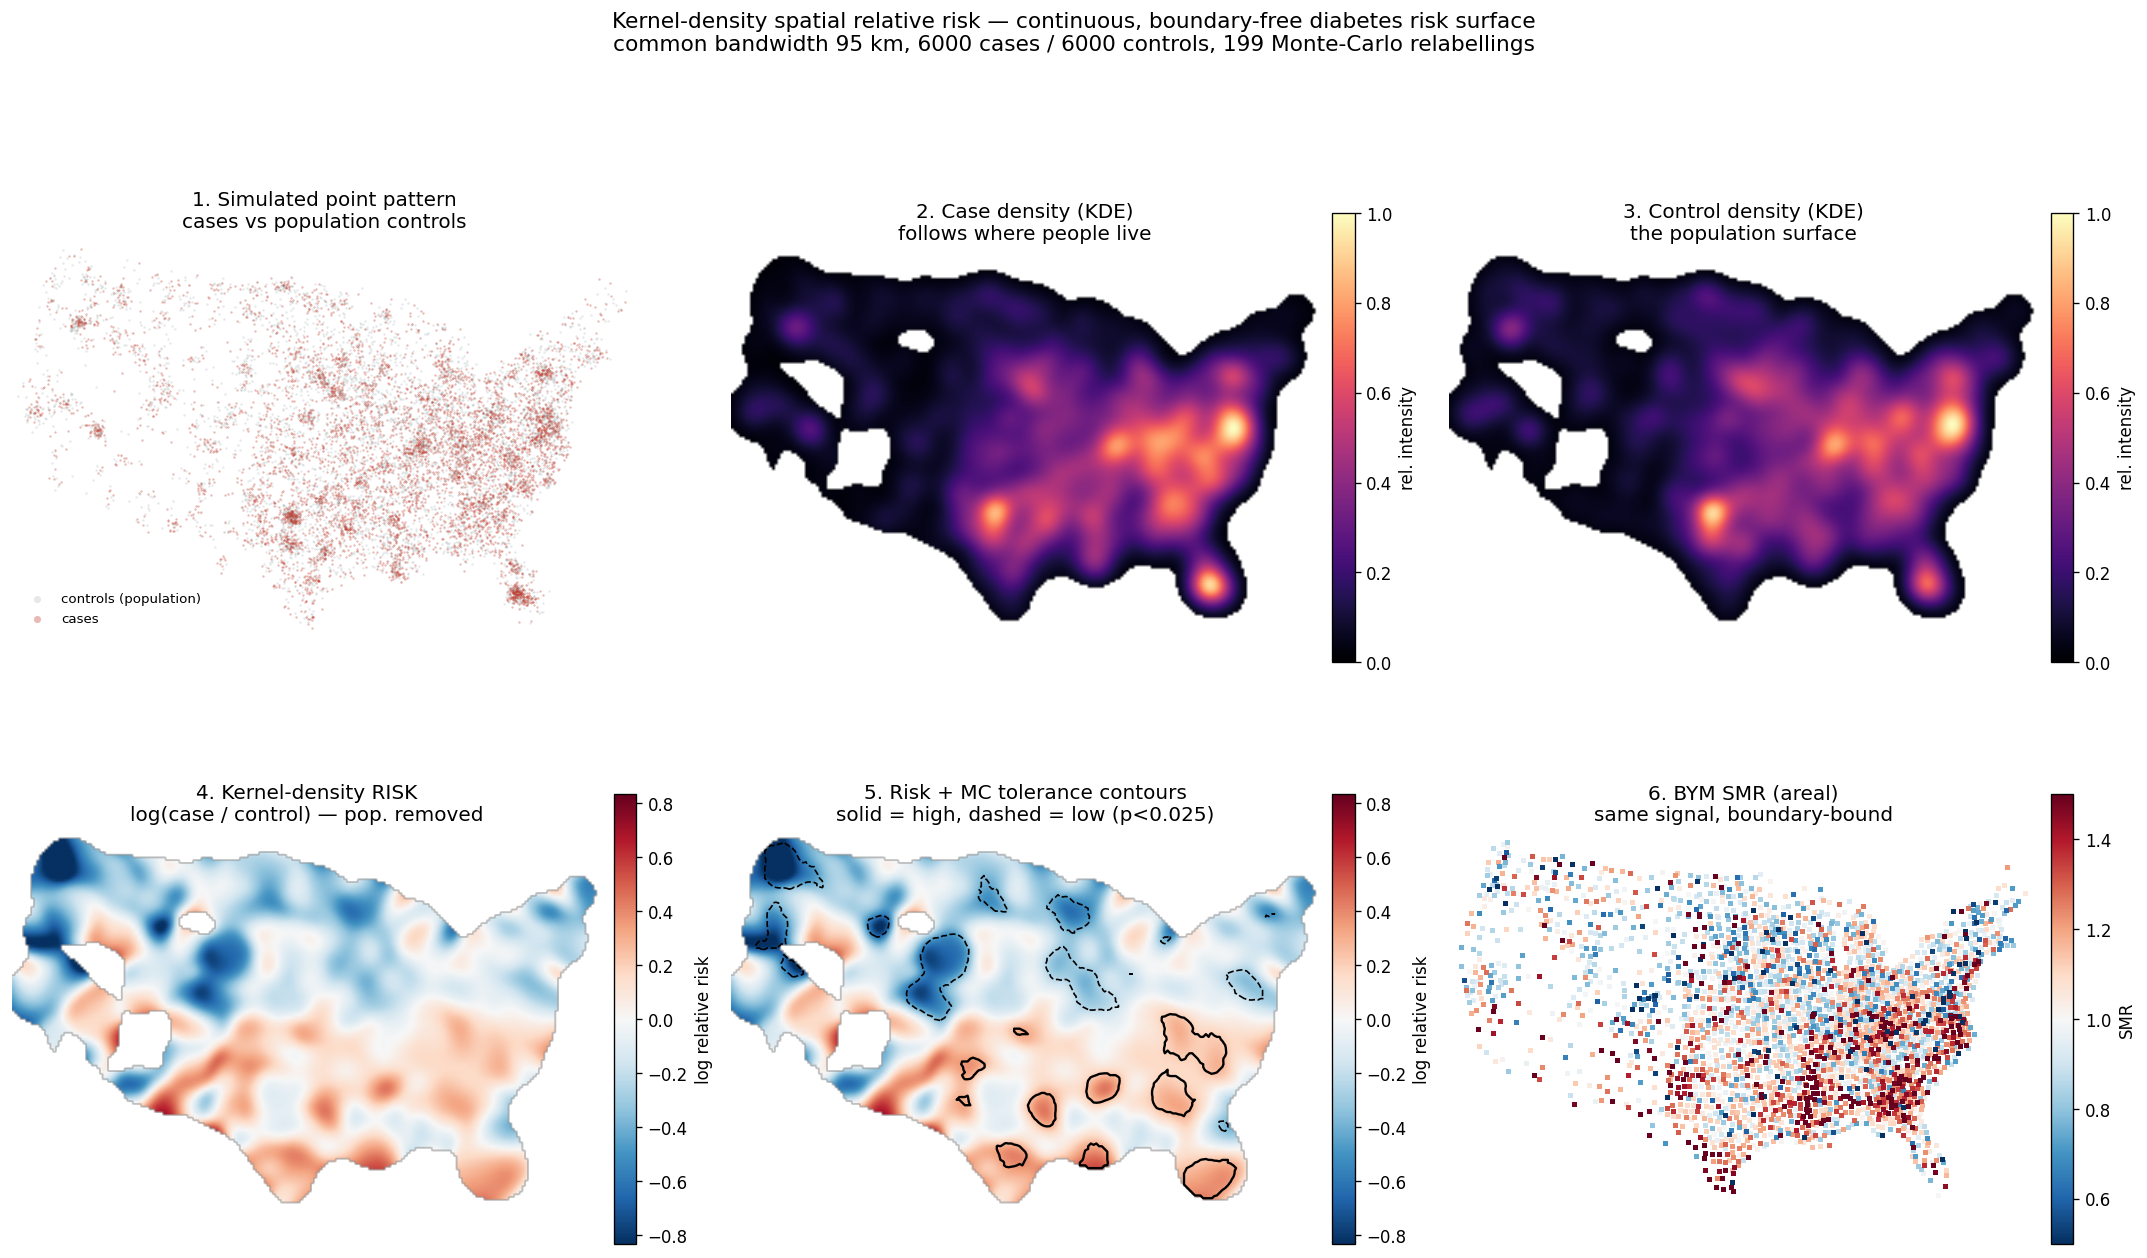

In [10]:

# ---- figure --------------------------------------------------------------- #
ext = [xmin, xmax, ymin, ymax]
XX, YY = np.meshgrid(xcen, ycen)                # (ny, nx) for contour
fig, ax = plt.subplots(2, 3, figsize=(18, 11))


def img(a, Z, title, cmap, norm=None, vmin=None, vmax=None, cbar=""):
    im = a.imshow(np.where(mask, Z, np.nan).T if Z.shape == mask.shape else Z.T,
                  origin="lower", extent=ext, cmap=cmap, norm=norm,
                  vmin=vmin, vmax=vmax, aspect="equal", interpolation="bilinear")
    a.set_title(title, fontsize=12)
    fig.colorbar(im, ax=a, fraction=0.036, pad=0.02).set_label(cbar)
    a.axis("off")


# 1 point pattern
ax[0, 0].scatter(ctrl_xy[:, 0], ctrl_xy[:, 1], s=2, c="#95a5a6", alpha=0.25,
                 linewidths=0, label="controls (population)")
ax[0, 0].scatter(case_xy[:, 0], case_xy[:, 1], s=2, c="#c0392b", alpha=0.35,
                 linewidths=0, label="cases")
ax[0, 0].set_title("1. Simulated point pattern\ncases vs population controls", fontsize=12)
ax[0, 0].set_xlim(xmin, xmax); ax[0, 0].set_ylim(ymin, ymax)
ax[0, 0].set_aspect("equal"); ax[0, 0].axis("off")
lg = ax[0, 0].legend(loc="lower left", frameon=False, fontsize=8, markerscale=3)

# 2 case KDE, 3 control KDE  (raw intensities — both track population)
img(ax[0, 1], Dc / Dc.max(), "2. Case density (KDE)\nfollows where people live",
    "magma", vmin=0, vmax=1, cbar="rel. intensity")
img(ax[0, 2], Dk / Dk.max(), "3. Control density (KDE)\nthe population surface",
    "magma", vmin=0, vmax=1, cbar="rel. intensity")

# 4 log relative risk
rlim = np.percentile(np.abs(logrr[mask]), 99)
rnorm = TwoSlopeNorm(vmin=-rlim, vcenter=0, vmax=rlim)
img(ax[1, 0], logrr, "4. Kernel-density RISK\nlog(case / control) — pop. removed",
    "RdBu_r", norm=rnorm, cbar="log relative risk")

# 5 risk + tolerance contours
img(ax[1, 1], logrr, "5. Risk + MC tolerance contours\nsolid = high, dashed = low (p<0.025)",
    "RdBu_r", norm=rnorm, cbar="log relative risk")
ax[1, 1].contour(XX, YY, np.where(mask, p_hi, 1).T, levels=[0.025],
                 colors="black", linewidths=1.4)
ax[1, 1].contour(XX, YY, np.where(mask, p_lo, 1).T, levels=[0.025],
                 colors="black", linewidths=1.0, linestyles="dashed")

# 6 BYM areal comparison
o = np.argsort(np.abs(bym - 1))
sc = ax[1, 2].scatter(coords[o, 0], coords[o, 1], c=bym[o], cmap="RdBu_r",
                      norm=TwoSlopeNorm(vmin=0.5, vcenter=1.0, vmax=1.5),
                      s=9, marker="s", linewidths=0)
ax[1, 2].set_title("6. BYM SMR (areal)\nsame signal, boundary-bound", fontsize=12)
ax[1, 2].set_xlim(xmin, xmax); ax[1, 2].set_ylim(ymin, ymax)
ax[1, 2].set_aspect("equal"); ax[1, 2].axis("off")
fig.colorbar(sc, ax=ax[1, 2], fraction=0.036, pad=0.02).set_label("SMR")

fig.suptitle("Kernel-density spatial relative risk — continuous, boundary-free "
             "diabetes risk surface\n"
             f"common bandwidth {h/1000:.0f} km, {N_CASE} cases / {N_CTRL} controls, "
             f"{B} Monte-Carlo relabellings", fontsize=13, y=1.02)
fig.tight_layout()


## 6. Knowledge Check

1. A county reports O=1 death with an expected E=0.8, resulting in an SMR of 1.25. However, the Empirical Bayes (EB)-smoothed estimate is 1.02.
   - **Why does Empirical Bayes shrink this estimate so strongly toward the mean?**
   > When observed counts are low, estimates are highly variable and more prone to random fluctuations rather than reflecting true underlying risk. Empirical Bayes shrinks these unstable estimates toward the global mean by borrowing information from the overall dataset, thereby reducing the influence of statistical noise—especially for counties with scant data.

2. In the BYM model, suppose the spatial random effect (sigma_u) is much larger than the non-spatial random effect (sigma_v).
   - **What does this reveal about spatial clustering of risk?**
   > A large sigma_u compared to sigma_v indicates that most variation in risk is explained by spatial structure: neighboring counties tend to have similar risk, pointing to strong spatial clustering, while non-spatial (random) variation plays a lesser role.

3. What potential issues arise if a researcher ranks counties for interventions using unsmoothed, raw SMR values?
   > Raw SMR estimates are especially noisy for counties with small populations or expected counts. Apparent 'extremes' can arise simply due to chance in these small-number areas, potentially resulting in intervention resources being misdirected based on statistical artifact rather than genuine need. Smoothing methods help mitigate these random outliers, producing more reliable rankings.

4. Why does the level of spatial autocorrelation (measured by Moran's I) increase after EB smoothing?
   Moran's I for raw SMR is 0.41, but for EB-SMR it's 0.55. **Why does smoothing increase spatial autocorrelation?**
   > EB smoothing incorporates information from neighboring regions, making estimates for geographically proximate counties more similar. This 'bleeds' risk estimates across borders, which strengthens spatial patterns, thereby increasing observed spatial autocorrelation.




***
**Next → NB-05: Spatial Cluster Detection (SaTScan-style)**
